In [12]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import (
    chi2_contingency, kruskal, mannwhitneyu, f_oneway,
    pointbiserialr, spearmanr, kendalltau, pearsonr,
)

# sklearn
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display + plot defaults
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Load the dataset
DATA_PATH = 'Data/OneDrive_1_5-17-2026/UConn_2026_data.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/OneDrive_1_5-17-2026/UConn_2026_data.csv'

Swagat Sainju

## Franchella Mariano

In [3]:
DATA_PATH = '/Users/franchellamariano/Downloads/UConn_2026_data(in).csv'  # update this path
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

Shape: (300000, 44)


,AUTO_POL_TRANS_ID,RISK_ST_ABBR,POL_EFF_DT,POL_EXP_DT,POL_NEW_RENEW_CD,POL_TTL_BILL_PREM_AMT,RISK_GRP,RISK_FLAG,CLTV_LONGVTY_GRP_CD,AARP_MEMB_YR_CNT,AARP_MEMB_IND,FULL_PAY_DISC_IND,POL_BI_OCCUR_LMT_CD,CLEAN_DIRTY_DESC,DRVR_TLMTC_PGM_TYP_CD,RENEW_YRS,POL_MULTI_SNGL_VEH_CD,POL_DRVR_TLMTC_ENROL_IND,ORIG_INTRNT_RATE_QTE_IND,PPV_CNT,PCARR_DESC,AVG_VEH_PREM,PCARR_YR_CNT,PCARR_CALC_YR_CNT,POL_FORM_CD,POL_RATE_DRVR_MIN_AGE,POL_RATE_DRVR_MAX_AGE,HH_COMP,ADV_QTE_DAY_CNT,AQD_GRP,YOUTHFUL_IND,BILL_PYMNT_METH_DESC,BILL_PYMENT_FREQ_DESC,AVG_VEHICLE_MILEAGE,MKT_CHNNL_NM,MKTG_MEDIA_GRP_DESC,MKTG_NON_BRAND_SEARCH_FLAG,ORIG_QTE_CNTCT_METH_CD,E_SIGN_IND,ECNSNT_BEGINING_OF_POL_TERM_IND,PLCY_MIN_CAR_BASE_PRICE,PLCY_MAX_CAR_BASE_PRICE,PLCY_AVG_CAR_BASE_PRICE,POL_ACCT_CR_IND
0,1064231476,CO,5/12/2025,11/12/2025,R,864.0,6,NaN,PL16,1,Y,1.0,500.0,Dirty,M,1.0,S,N,N,1,Others,864.00,2.0,2.9,0,63,63,SC1D,50.0,14-60,N,CreditOrDebitCard,PayInFull,10000,Search,AARP Branded,Other than Non-Branded Search,P,0,1,23245.0,23245.0,23245.0,0
1,1018298329,WI,3/2/2023,9/2/2023,N,287.0,9,NaN,PL22,1,Y,1.0,300.0,Dirty,X,0.0,S,N,Y,1,Others,287.00,1.0,0.9,H*,24,59,SCMT1D,25.0,14-60,Y,CreditOrDebitCard,RepetitiveFullPay,8000,Online,HIG.com,Other than Non-Branded Search,I,1,1,27170.0,27170.0,27170.0,0
2,1057068242,FL,9/24/2024,3/24/2025,R,980.0,5,NaN,NaN,8,Y,0.0,20.0,Dirty,X,2.5,S,Y,N,1,Others,980.00,2.0,2.8,H*,58,58,SC1D,82.0,75+,N,BankAccount,MonthlyAutoPay,11000,Direct Mail,Winback,Other than Non-Branded Search,P,1,1,21045.0,21045.0,21045.0,0
3,1044629296,FL,9/24/2024,3/24/2025,R,2079.0,8,NaN,NaN,12,Y,0.0,500.0,Clean,X,1.0,M,N,N,2,Geico,1039.50,5.0,6.2,H*,64,71,MC C=D,27.0,14-60,N,BankAccount,MonthlyAutoPay,10000,NaN,NaN,Other than Non-Branded Search,P,1,0,25095.0,29705.0,27400.0,0
4,1053922228,SC,7/13/2024,1/13/2025,R,3925.0,1,NaN,PL24,1,Y,0.0,50.0,Dirty,X,0.5,M,Y,Y,3,Others,1308.33,5.0,3.9,0,39,61,MCMCTD,15.0,14-60,N,BankAccount,MonthlyAutoPay,12453,Search,Non Branded,Search Non Branded,I,1,1,22970.0,32190.0,27392.0,0


In [16]:
num_cols = df.select_dtypes(include="number").drop(columns=["POL_ACCT_CR_IND"])

results_num = []

for col in num_cols.columns:
    x = num_cols[col].fillna(num_cols[col].median())

    r, p = pointbiserialr(x, target)

    results_num.append([col, "point-biserial", r, p])

num_results = pd.DataFrame(results_num, columns=[
    "feature", "test", "statistic_r", "p_value"
])

num_results.sort_values("statistic_r", ascending=False)

,feature,test,statistic_r,p_value
5,POL_BI_OCCUR_LMT_CD,point-biserial,0.243631,0.000000e+00
2,RISK_GRP,point-biserial,0.157275,0.000000e+00
3,AARP_MEMB_YR_CNT,point-biserial,0.138809,0.000000e+00
0,AUTO_POL_TRANS_ID,point-biserial,0.107053,0.000000e+00
12,POL_RATE_DRVR_MAX_AGE,point-biserial,0.094542,0.000000e+00
4,FULL_PAY_DISC_IND,point-biserial,0.078666,0.000000e+00
7,PPV_CNT,point-biserial,0.071928,0.000000e+00
11,POL_RATE_DRVR_MIN_AGE,point-biserial,0.057112,3.768702e-215
13,ADV_QTE_DAY_CNT,point-biserial,0.048869,5.132263e-158
9,PCARR_YR_CNT,point-biserial,0.042162,4.268232e-118


In [18]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

results_cat = []

for col in df.select_dtypes(include="object").columns:
    x = df[col].fillna("Missing")

    chi2, p, dof, exp = chi2_contingency(pd.crosstab(x, target))
    v = cramers_v(x, target)

    results_cat.append([col, "chi-square + Cramér's V", v, p])

cat_results = pd.DataFrame(results_cat, columns=[
    "feature", "test", "effect_size", "p_value"
])

cat_results.sort_values("effect_size", ascending=False)

,feature,test,effect_size,p_value
13,POL_FORM_CD,chi-square + Cramér's V,0.999446,0.000000e+00
5,CLTV_LONGVTY_GRP_CD,chi-square + Cramér's V,0.502679,0.000000e+00
0,RISK_ST_ABBR,chi-square + Cramér's V,0.412982,0.000000e+00
17,BILL_PYMNT_METH_DESC,chi-square + Cramér's V,0.216211,0.000000e+00
12,PCARR_DESC,chi-square + Cramér's V,0.157565,0.000000e+00
1,POL_EFF_DT,chi-square + Cramér's V,0.144966,0.000000e+00
2,POL_EXP_DT,chi-square + Cramér's V,0.144649,0.000000e+00
8,DRVR_TLMTC_PGM_TYP_CD,chi-square + Cramér's V,0.116700,0.000000e+00
20,MKTG_MEDIA_GRP_DESC,chi-square + Cramér's V,0.113879,0.000000e+00
14,HH_COMP,chi-square + Cramér's V,0.104923,0.000000e+00


In [19]:
num_results2 = num_results.copy()
num_results2 = num_results2.rename(columns={"statistic_r": "effect_size"})
num_results2 = num_results2[["feature", "test", "effect_size", "p_value"]]

cat_results2 = cat_results

full_table = pd.concat([num_results2, cat_results2], ignore_index=True)
full_table.sort_values("effect_size", ascending=False)

,feature,test,effect_size,p_value
33,POL_FORM_CD,chi-square + Cramér's V,0.999446,0.000000e+00
25,CLTV_LONGVTY_GRP_CD,chi-square + Cramér's V,0.502679,0.000000e+00
20,RISK_ST_ABBR,chi-square + Cramér's V,0.412982,0.000000e+00
5,POL_BI_OCCUR_LMT_CD,point-biserial,0.243631,0.000000e+00
37,BILL_PYMNT_METH_DESC,chi-square + Cramér's V,0.216211,0.000000e+00
32,PCARR_DESC,chi-square + Cramér's V,0.157565,0.000000e+00
2,RISK_GRP,point-biserial,0.157275,0.000000e+00
21,POL_EFF_DT,chi-square + Cramér's V,0.144966,0.000000e+00
22,POL_EXP_DT,chi-square + Cramér's V,0.144649,0.000000e+00
3,AARP_MEMB_YR_CNT,point-biserial,0.138809,0.000000e+00


##### Final Feature Ranking

In [20]:
num_results2 = num_results.copy()
num_results2 = num_results2.rename(columns={"statistic_r": "effect_size"})
num_results2 = num_results2[["feature", "test", "effect_size", "p_value"]]

cat_results2 = cat_results

full_table = pd.concat([num_results2, cat_results2], ignore_index=True)
full_table.sort_values("effect_size", ascending=False)

,feature,test,effect_size,p_value
33,POL_FORM_CD,chi-square + Cramér's V,0.999446,0.000000e+00
25,CLTV_LONGVTY_GRP_CD,chi-square + Cramér's V,0.502679,0.000000e+00
20,RISK_ST_ABBR,chi-square + Cramér's V,0.412982,0.000000e+00
5,POL_BI_OCCUR_LMT_CD,point-biserial,0.243631,0.000000e+00
37,BILL_PYMNT_METH_DESC,chi-square + Cramér's V,0.216211,0.000000e+00
32,PCARR_DESC,chi-square + Cramér's V,0.157565,0.000000e+00
2,RISK_GRP,point-biserial,0.157275,0.000000e+00
21,POL_EFF_DT,chi-square + Cramér's V,0.144966,0.000000e+00
22,POL_EXP_DT,chi-square + Cramér's V,0.144649,0.000000e+00
3,AARP_MEMB_YR_CNT,point-biserial,0.138809,0.000000e+00


##### Payment Method

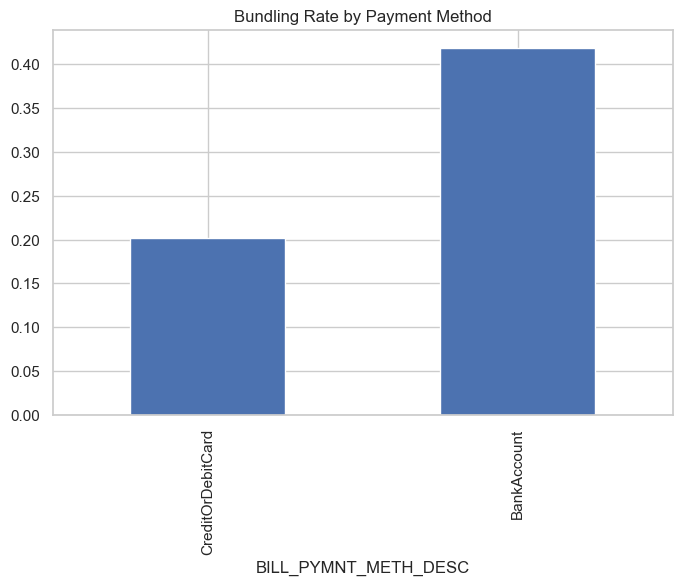

In [21]:
rate = df.groupby("BILL_PYMNT_METH_DESC")["POL_ACCT_CR_IND"].mean()

rate.sort_values().plot(kind="bar")
plt.title("Bundling Rate by Payment Method")
plt.show()

##### Target Class Imbalance

Counts:
 POL_ACCT_CR_IND
0    196716
1    103284
Name: count, dtype: int64

Proportions:
 POL_ACCT_CR_IND
0    0.65572
1    0.34428
Name: proportion, dtype: float64


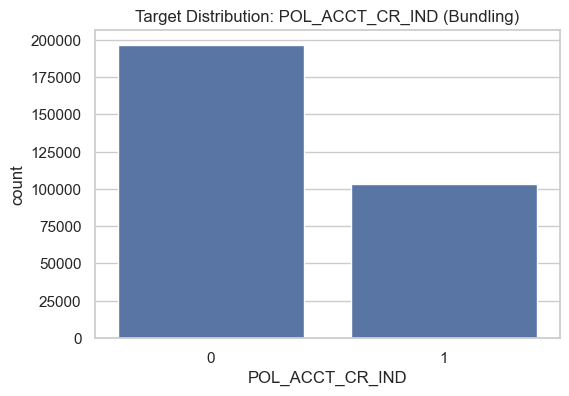

Imbalance ratio: 1.9046125246892065


In [22]:
target = df["POL_ACCT_CR_IND"]

target_counts = target.value_counts()
target_props = target.value_counts(normalize=True)

print("Counts:\n", target_counts)
print("\nProportions:\n", target_props)

plt.figure(figsize=(6,4))
sns.countplot(x=target)
plt.title("Target Distribution: POL_ACCT_CR_IND (Bundling)")
plt.show()

imbalance_ratio = target.value_counts().max() / target.value_counts().min()

print("Imbalance ratio:", imbalance_ratio)

##### Risk Group

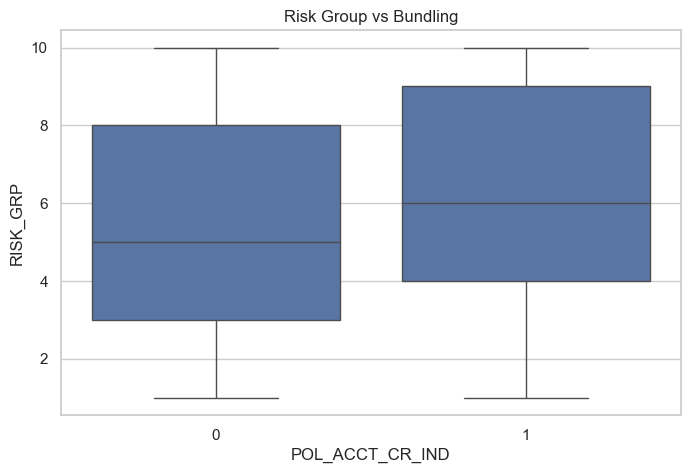

In [23]:
sns.boxplot(x=target, y=df["RISK_GRP"])
plt.title("Risk Group vs Bundling")
plt.show()

##### Coverage Limit

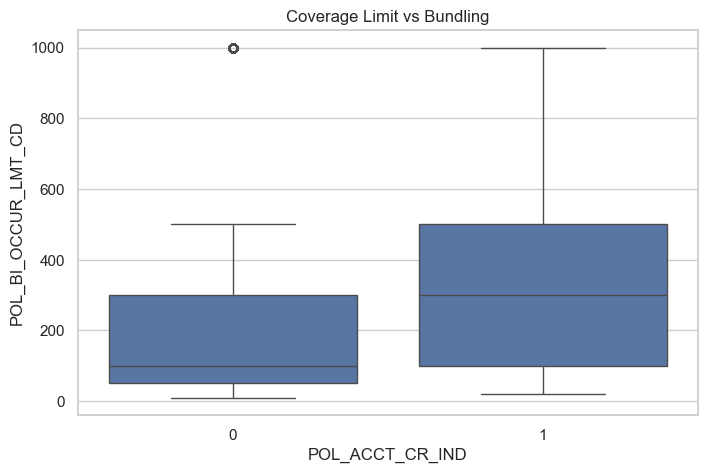

In [24]:
sns.boxplot(x=target, y=df["POL_BI_OCCUR_LMT_CD"])
plt.title("Coverage Limit vs Bundling")
plt.show()

The boxplots show that customers who bundle (1) tend to have slightly higher risk group scores and notably higher coverage limits compared to non-bundlers (0), suggesting bundlers are more protection- and coverage-oriented. Overall, this indicates bundling is associated with higher risk classification and greater policy coverage levels.

##### Correlation Heatmap

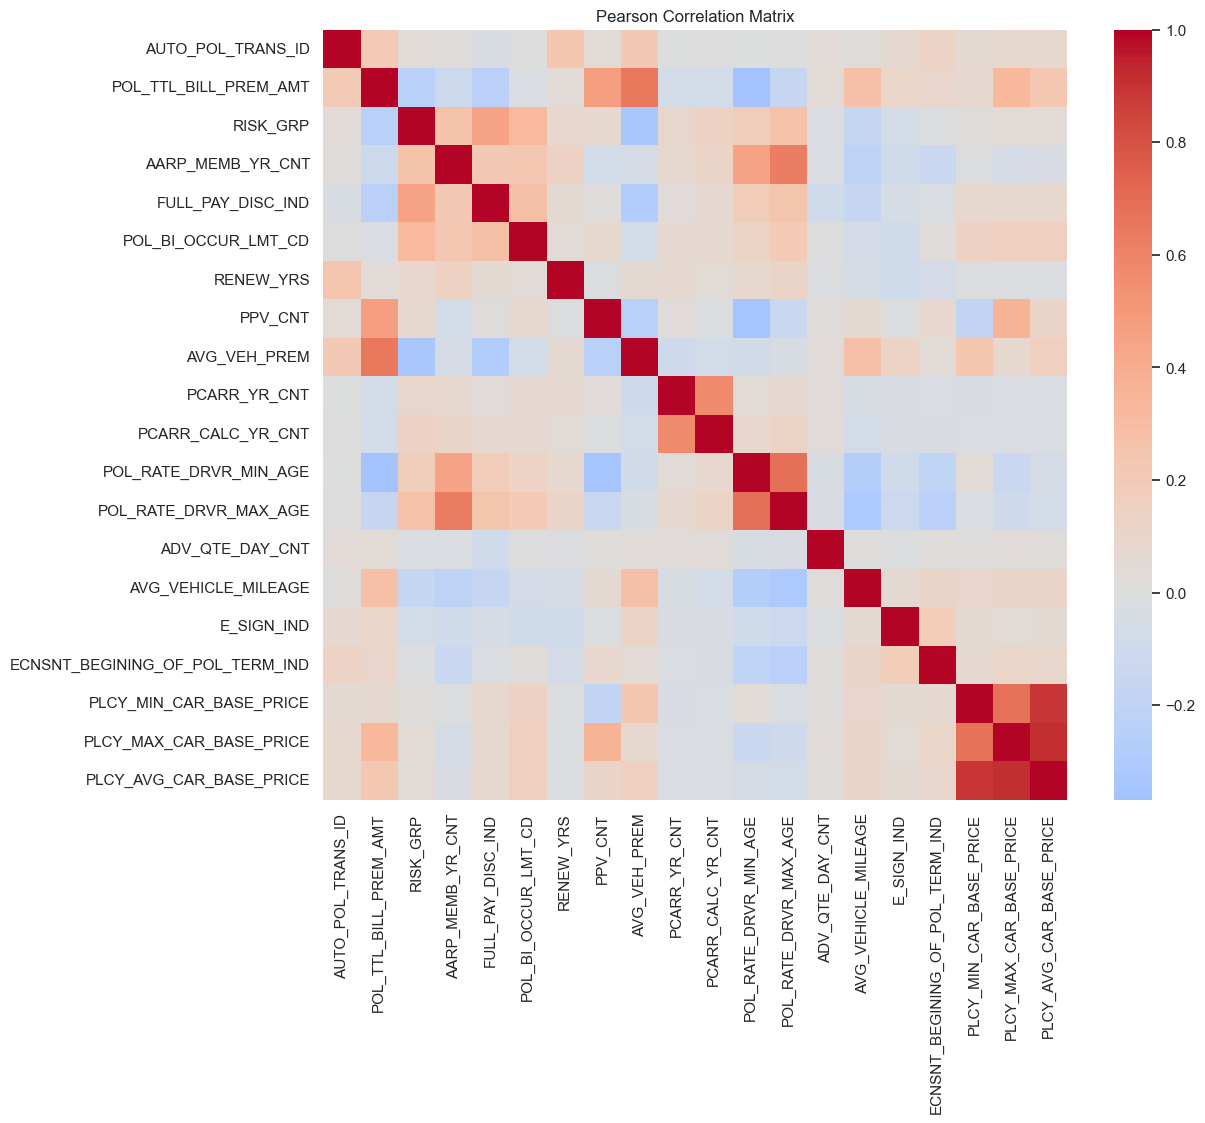

In [25]:
num_df = df.select_dtypes(include="number").drop(columns=["POL_ACCT_CR_IND"])

pearson_corr = num_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix")
plt.show()

The correlation heatmap shows mostly weak-to-moderate relationships across features, with the strongest clustering among vehicle price variables and some age/tenure-related variables. No single predictor overwhelmingly dominates, reinforcing that bundling behavior is driven by a combination of behavioral and policy-structure features rather than one standalone variable.

##### MI Computation

In [26]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["POL_ACCT_CR_IND"]).copy()
y = df["POL_ACCT_CR_IND"]

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.fillna(X.median(numeric_only=True))

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    "feature": X.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

mi_results

,feature,mutual_information
24,POL_FORM_CD,0.652835
8,CLTV_LONGVTY_GRP_CD,0.140029
1,RISK_ST_ABBR,0.114624
12,POL_BI_OCCUR_LMT_CD,0.054721
38,E_SIGN_IND,0.044435
10,AARP_MEMB_IND,0.042956
16,POL_MULTI_SNGL_VEH_CD,0.039950
14,DRVR_TLMTC_PGM_TYP_CD,0.038090
39,ECNSNT_BEGINING_OF_POL_TERM_IND,0.036176
7,RISK_FLAG,0.035949


##### MI Plot

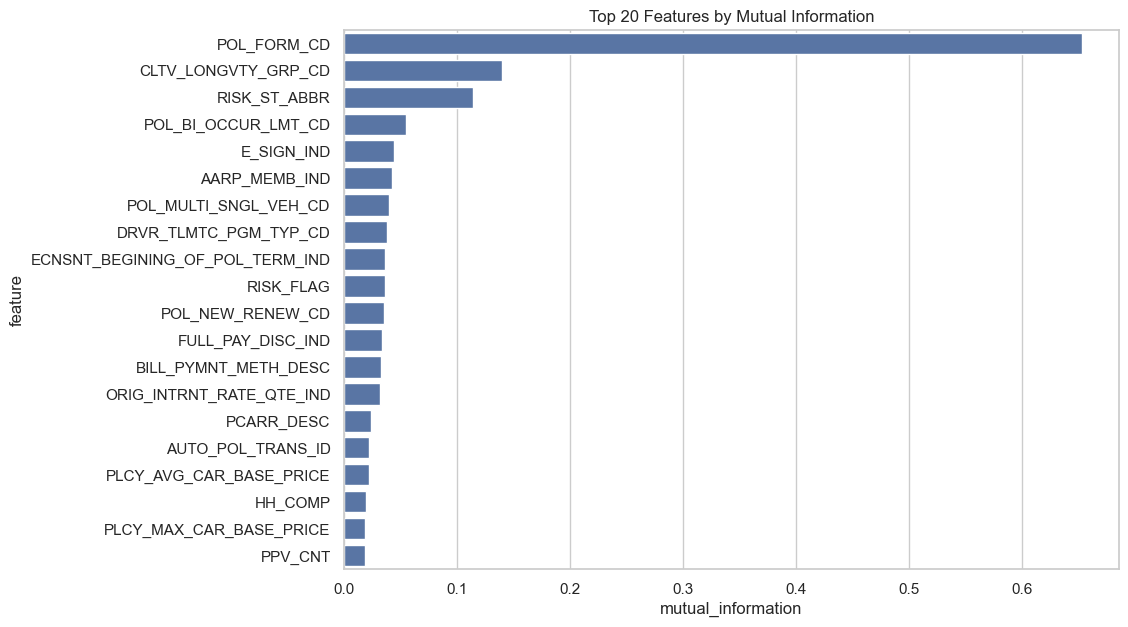

In [27]:
top20 = mi_results.head(20)

plt.figure(figsize=(10,7))
sns.barplot(data=top20, y="feature", x="mutual_information")
plt.title("Top 20 Features by Mutual Information")
plt.show()

This table shows the mutual information score for each feature with the target variable, which measures how much each variable helps reduce uncertainty in predicting the outcome. Higher values indicate stronger predictive power, with POL_FORM_CD standing out as unusually high and likely a case of data leakage. 

Without POL_FORM_CD, the strongest signal comes from customer lifecycle and policy structure variables, especially CLTV_LONGVTY_GRP_CD, which has the highest remaining mutual information and suggests customer tenure and value are key drivers of the target. Moderate signals also appear in variables like RISK_ST_ABBR and POL_BI_OCCUR_LMT_CD, indicating that risk profile and coverage choices contribute meaningfully to prediction. 

Overall, the rest of the features show relatively low mutual information, meaning the signal is spread across many weak predictors rather than dominated by a few strong ones.
